In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
from tensorflow.keras.preprocessing.image import ImageDataGenerator # type: ignore
from tensorflow.keras import layers, models # type: ignore
from tensorflow.keras.models import Model, load_model # type: ignore
import matplotlib.pyplot as plt
import os
import json
from PIL import Image
import shutil
from pathlib import Path

In [2]:
print("--- GPU Detection Status ---")
print(tf.config.list_physical_devices('GPU'))
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

--- GPU Detection Status ---
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Num GPUs Available:  1


In [3]:
source_dirs = r'C:\NEWHELPTHEGREEN\health_classifier'

In [4]:
#Step 3: Data generators with augmentations
from tensorflow.keras.preprocessing.image import ImageDataGenerator  # type: ignore

image_size = 128
batch_size = 8
train_dir = 'health_classifier/train'
val_dir = 'health_classifier/val'

# --- 1. Define Augmentation without validation_split ---
train_datagen = ImageDataGenerator(
    rescale=1./255,
    brightness_range=[0.8, 1.2],
    channel_shift_range=0.2,
    zoom_range=0.3,
    rotation_range=30,
    horizontal_flip=True,
    vertical_flip=True,
    width_shift_range=0.2,
    height_shift_range=0.2,
    fill_mode='nearest'
)

# --- 2. Define Validation Generator (Only Rescaling) ---
val_datagen = ImageDataGenerator(rescale=1./255) 

# --- 3. Create Training Generator ---
train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=(image_size, image_size),
    batch_size=batch_size,
    class_mode='categorical',
)

# --- 4. Create Validation Generator ---
val_gen = val_datagen.flow_from_directory(
    val_dir,
    target_size=(image_size, image_size),
    batch_size=batch_size,
    class_mode='categorical',
)

num_classes = train_gen.num_classes

print(f"Number of classes detected: {num_classes}")
print(f"Classes found by generator: {train_gen.class_indices}")

Found 4978 images belonging to 2 classes.
Found 1052 images belonging to 2 classes.
Number of classes detected: 2
Classes found by generator: {'diseased': 0, 'healthy': 1}


In [5]:
# Count samples per class
total_diseased = len(os.listdir('health_classifier/train/diseased'))
total_healthy = len(os.listdir('health_classifier/train/healthy'))
total_samples = total_diseased + total_healthy

print(f"Diseased samples: {total_diseased}")
print(f"Healthy samples: {total_healthy}")
print(f"Total samples: {total_samples}")

# Calculate weights (give more weight to underrepresented class)
weight_diseased = total_samples / (2 * total_diseased)
weight_healthy = total_samples / (2 * total_healthy)

class_weights = {
    0: weight_diseased,    # diseased (usually smaller)
    1: weight_healthy      # healthy
}

print(f"\nClass weights:")
print(f"  Diseased: {weight_diseased:.4f}")
print(f"  Healthy: {weight_healthy:.4f}")

Diseased samples: 2906
Healthy samples: 2072
Total samples: 4978

Class weights:
  Diseased: 0.8565
  Healthy: 1.2013


In [6]:
import keras_tuner as kt
from tensorflow.keras.optimizers import Adam # type: ignore
from tensorflow.keras.layers import BatchNormalization # type: ignore #
from tensorflow.keras import layers, models # type: ignore
import json

# Define the model architecture for hyperparameter tuning
def build_model(hp):
    model = models.Sequential()
    
    # --- Conv Block 1 ---
    model.add(layers.Conv2D(
        filters=hp.Int('conv_1_filters', 32, 128, step=32),
        kernel_size=(3, 3),
        activation='relu',
        input_shape=(image_size, image_size, 3)
    ))
    model.add(BatchNormalization()) 
    model.add(layers.MaxPooling2D(2, 2))
    
    # --- Conv Block 2 ---
    model.add(layers.Conv2D(
        filters=hp.Int('conv_2_filters', 64, 256, step=64),
        kernel_size=(3, 3),
        activation='relu'
    ))
    model.add(BatchNormalization())
    model.add(layers.MaxPooling2D(2, 2))
    
    # --- Conv Block 3 ---
    model.add(layers.Conv2D(
        filters=hp.Int('conv_3_filters', 128, 512, step=128),
        kernel_size=(3, 3),
        activation='relu'
    ))
    model.add(BatchNormalization())
    model.add(layers.MaxPooling2D(2, 2))
    
    model.add(layers.Flatten())
    model.add(layers.Dense(
        hp.Int('dense_units', 128, 512, step=128),
        activation='relu'
    ))
    model.add(layers.Dropout(hp.Float('dropout', 0.2, 0.5, step=0.1)))
    model.add(layers.Dense(num_classes, activation='softmax'))
    
    model.compile(
        optimizer=Adam(learning_rate=hp.Float('learning_rate', 1e-5, 1e-2, sampling='log')),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# Initialize the RandomSearch tuner
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=3,
    executions_per_trial=1,
    directory='keras_tuner_dir',
    project_name='HelpTheGreen'
)

print("Starting Hyperparameter Search (3 Trials x 5 Epochs each)...")
tuner.search(train_gen, epochs=5, validation_data=val_gen)
print("Hyperparameter Search Complete.")

# Get the best model and train it for 5 epochs
best_hps = tuner.get_best_hyperparameters(1)[0]
print("\nBest hyperparameters found:")
for param in best_hps.values:
    print(f"{param}: {best_hps.get(param)}")
model = tuner.hypermodel.build(best_hps)

print("\nStarting Final Model Training (50 Epochs)...")
history = model.fit(train_gen, epochs=100, validation_data=val_gen, class_weight=class_weights)

# Save model and class labels locally
model.save('plantvillage_tuned_model.h5')
class_labels = {v: k for k, v in train_gen.class_indices.items()}

with open('class_labels_combined.json', 'w') as f:
    json.dump(class_labels, f)

print("Final tuned model and class labels saved locally.")

Reloading Tuner from keras_tuner_dir\HelpTheGreen\tuner0.json
Starting Hyperparameter Search (3 Trials x 5 Epochs each)...
Hyperparameter Search Complete.

Best hyperparameters found:
conv_1_filters: 128
conv_2_filters: 128
conv_3_filters: 128
dense_units: 512
dropout: 0.30000000000000004
learning_rate: 1.3419183387464394e-05

Starting Final Model Training (50 Epochs)...
Epoch 1/100
623/623 [==============================] - 81s 105ms/step - loss: 0.9616 - accuracy: 0.5932 - val_loss: 0.5868 - val_accuracy: 0.6740
Epoch 2/100
623/623 [==============================] - 67s 107ms/step - loss: 0.7406 - accuracy: 0.6485 - val_loss: 0.6077 - val_accuracy: 0.7072
Epoch 3/100
623/623 [==============================] - 68s 110ms/step - loss: 0.6574 - accuracy: 0.6792 - val_loss: 0.5874 - val_accuracy: 0.6825
Epoch 4/100
623/623 [==============================] - 57s 91ms/step - loss: 0.6214 - accuracy: 0.6862 - val_loss: 0.5746 - val_accuracy: 0.7129
Epoch 5/100
623/623 [======================

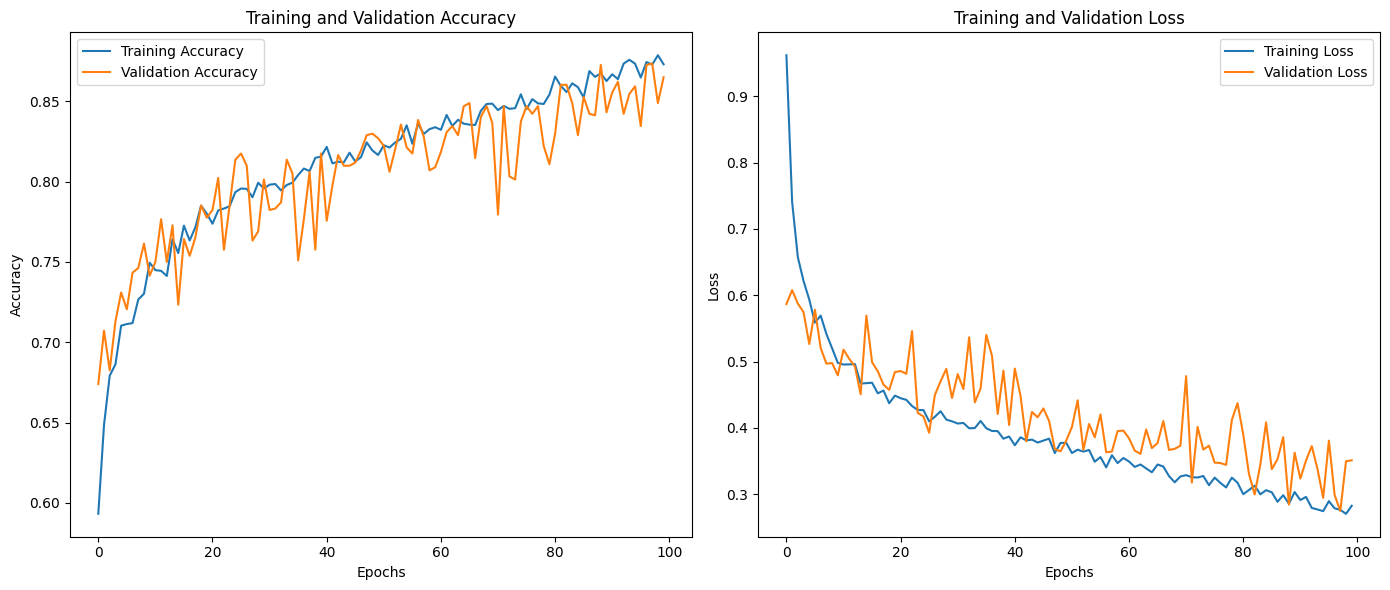

In [7]:
import matplotlib.pyplot as plt
%matplotlib inline

def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(14, 6))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.legend()
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.legend()
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')

    plt.tight_layout()
    plt.show()

plot_history(history)


In [8]:
for epoch in range(len(history.history['accuracy'])):
    print(f"Epoch {epoch+1}:")
    print(f"  Training Accuracy:  {history.history['accuracy'][epoch]:.4f}")
    print(f"  Validation Accuracy:{history.history['val_accuracy'][epoch]:.4f}")
    print(f"  Training Loss:      {history.history['loss'][epoch]:.4f}")
    print(f"  Validation Loss:    {history.history['val_loss'][epoch]:.4f}")


Epoch 1:
  Training Accuracy:  0.5932
  Validation Accuracy:0.6740
  Training Loss:      0.9616
  Validation Loss:    0.5868
Epoch 2:
  Training Accuracy:  0.6485
  Validation Accuracy:0.7072
  Training Loss:      0.7406
  Validation Loss:    0.6077
Epoch 3:
  Training Accuracy:  0.6792
  Validation Accuracy:0.6825
  Training Loss:      0.6574
  Validation Loss:    0.5874
Epoch 4:
  Training Accuracy:  0.6862
  Validation Accuracy:0.7129
  Training Loss:      0.6214
  Validation Loss:    0.5746
Epoch 5:
  Training Accuracy:  0.7103
  Validation Accuracy:0.7310
  Training Loss:      0.5935
  Validation Loss:    0.5265
Epoch 6:
  Training Accuracy:  0.7113
  Validation Accuracy:0.7205
  Training Loss:      0.5587
  Validation Loss:    0.5782
Epoch 7:
  Training Accuracy:  0.7119
  Validation Accuracy:0.7433
  Training Loss:      0.5693
  Validation Loss:    0.5205
Epoch 8:
  Training Accuracy:  0.7266
  Validation Accuracy:0.7462
  Training Loss:      0.5418
  Validation Loss:    0.4970


Generating predictions on validation set...
132/132 [==============================] - 5s 31ms/step

--- Classification Report ---
              precision    recall  f1-score   support

    diseased       0.55      0.50      0.52       590
     healthy       0.43      0.47      0.45       462

    accuracy                           0.49      1052
   macro avg       0.49      0.49      0.49      1052
weighted avg       0.49      0.49      0.49      1052



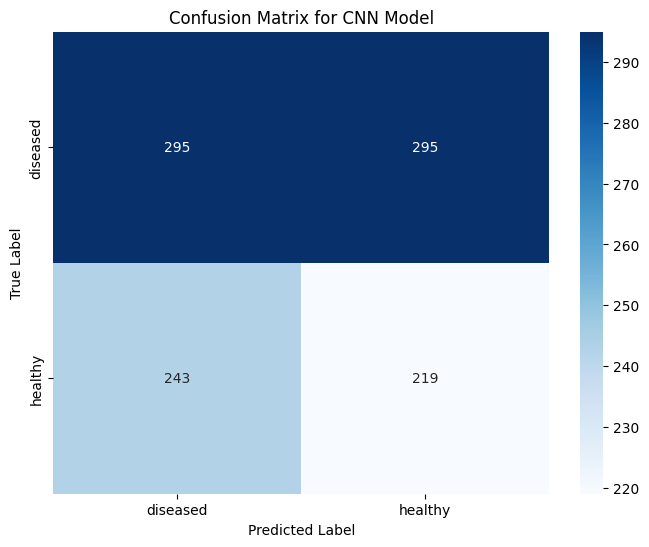

In [9]:
from sklearn.metrics import confusion_matrix, classification_report # type: ignore
import seaborn as sns # type: ignore

# 1. Get True Labels and Predictions from the Validation Set
print("Generating predictions on validation set...")

# Reset generator to ensure it starts from the beginning
val_gen.reset() 

# Predict the categories for all validation images
# steps = total number of validation samples / batch size
val_steps = val_gen.samples // val_gen.batch_size 
if val_gen.samples % val_gen.batch_size != 0:
    val_steps += 1
    
Y_pred = model.predict(val_gen, steps=val_steps)
y_pred_classes = np.argmax(Y_pred, axis=1) # Predicted classes (e.g., 0, 1)

# Get true classes (ensure generator is not shuffled)
y_true = val_gen.classes # True classes (e.g., 0, 1)

# Get class labels from the generator
class_names = list(train_gen.class_indices.keys())

# 2. Compute Confusion Matrix
conf_matrix = confusion_matrix(y_true, y_pred_classes)

# 3. Print Classification Report (Precision, Recall, F1-score)
print("\n--- Classification Report ---")
print(classification_report(y_true, y_pred_classes, target_names=class_names))

# 4. Plot Confusion Matrix (for report visualization)
plt.figure(figsize=(8, 6))
sns.heatmap(
    conf_matrix, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=class_names, 
    yticklabels=class_names
)
plt.title('Confusion Matrix for CNN Model')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

132/132 [==============================] - 4s 30ms/step


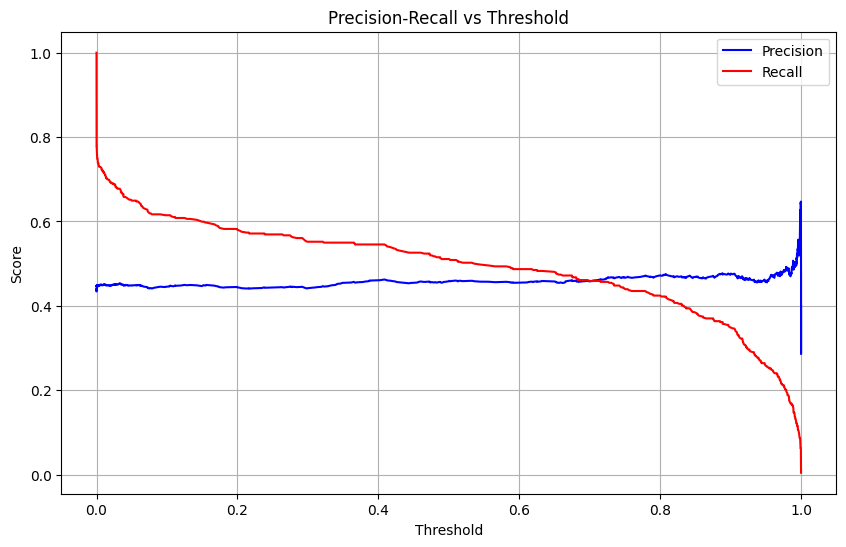


✅ Optimal Threshold: 0.0000
   - Precision: 43.92%
   - Recall: 100.00%
   - F1-Score: 61.03%


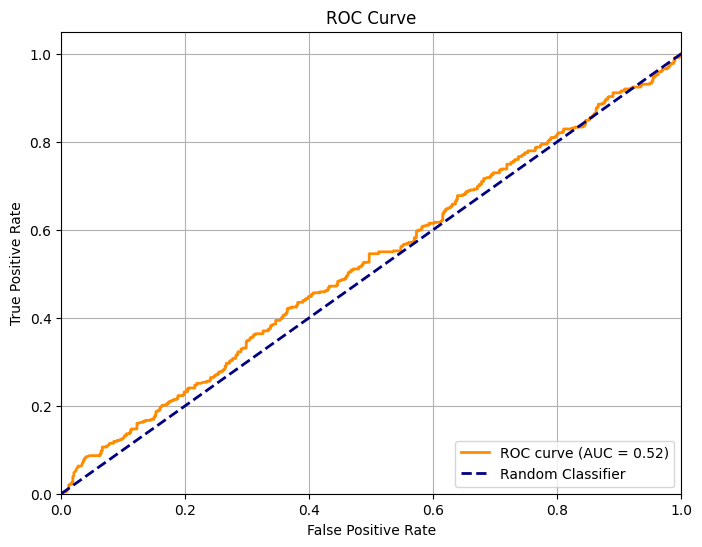


📊 ROC-AUC Score: 0.5240


In [10]:
# ===== FIND OPTIMAL THRESHOLD =====
from sklearn.metrics import precision_recall_curve, roc_curve, auc
import matplotlib.pyplot as plt

# Get probability predictions for healthy class (index 1)
val_gen.reset()
y_proba = model.predict(val_gen, steps=val_steps)[:, 1]  # Probabilities for "healthy"

# Calculate precision-recall curve
precisions, recalls, thresholds = precision_recall_curve(y_true, y_proba)

# Plot Precision-Recall Curve
plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions[:-1], 'b-', label='Precision')
plt.plot(thresholds, recalls[:-1], 'r-', label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall vs Threshold')
plt.legend()
plt.grid(True)
plt.show()

# Find optimal threshold (where precision and recall are balanced)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
optimal_idx = np.argmax(f1_scores[:-1])
optimal_threshold = thresholds[optimal_idx]

print(f"\n✅ Optimal Threshold: {optimal_threshold:.4f}")
print(f"   - Precision: {precisions[optimal_idx]:.2%}")
print(f"   - Recall: {recalls[optimal_idx]:.2%}")
print(f"   - F1-Score: {f1_scores[optimal_idx]:.2%}")

# Calculate ROC-AUC
fpr, tpr, _ = roc_curve(y_true, y_proba)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

print(f"\n📊 ROC-AUC Score: {roc_auc:.4f}")

In [ ]:
import numpy as np
from PIL import Image
from tensorflow.keras.models import load_model # type: ignore
model = load_model('plantvillage_tuned_model.h5')
def quick_predict(image_path):
     img = Image.open(image_path).convert("RGB").resize((128, 128))
     arr = np.expand_dims(np.array(img, dtype='float32') / 255.0, axis=0)
     pred = model.predict(arr, verbose=0)[0]
     if pred[1] < 0.35:
          return "🔴 DISEASED"
     return "🟢 HEALTHY"
# Test on your image
print(quick_predict(r"C:\Users\majum\Downloads\images (9).jpeg"))

🔴 DISEASED
